In [8]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


# Estimator wrapper demo

Quick sanity check for the `Estimator` that combines `AbstractGraphTransformer`, an optional manifold step, and a downstream scikit estimator.

In [9]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from abstractgraph.utils import plot_dataset_method_bars, plot_pareto
from IPython.core.display import HTML
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import os
import warnings
warnings.filterwarnings("ignore", message="n_jobs value .*overridden")
os.environ.setdefault("KMP_WARNINGS", "0")
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

from abstractgraph.vectorize import AbstractGraphTransformer
from abstractgraph_ml.estimators import GraphEstimator


def compute_metrics(y_true, y_pred, proba=None):
    acc = accuracy_score(y_true, y_pred)
    auc = None
    ap = None
    if proba is not None:
        classes = np.unique(y_true)
        if len(classes) > 1:
            # Handle binary separately for cleaner metrics.
            try:
                if len(classes) == 2:
                    pos_idx = 1 if proba.shape[1] > 1 else 0
                    scores = proba[:, pos_idx]
                    auc = roc_auc_score(y_true, scores)
                    ap = average_precision_score(y_true, scores)
                else:
                    auc = roc_auc_score(y_true, proba, multi_class="ovr")
                    y_bin = label_binarize(y_true, classes=classes)
                    ap = average_precision_score(y_bin, proba, average="macro")
            except Exception:
                auc = auc if "auc" in locals() else None
                ap = ap if "ap" in locals() else None
    return acc, auc, ap

def plot_benchmark_comparison(report_df, metric="accuracy", columns=("decomposition", "classifier"), ax=None, auto_zero=True):
    """Grouped bar plot to compare benchmark dimensions side by side per assay."""
    if report_df is None or report_df.empty:
        raise ValueError("report_df is empty")
    if metric not in report_df.columns:
        raise ValueError(f"metric {metric} not in report_df")
    missing_columns = [column for column in columns if column not in report_df.columns]
    if missing_columns:
        raise ValueError(f"columns missing from report_df: {missing_columns}")
    plot_df = report_df.copy()
    comparison_column = "comparison"
    plot_df[comparison_column] = plot_df.loc[:, list(columns)].astype(str).agg(" / ".join, axis=1)
    pivot = plot_df.pivot_table(index="assay_id", columns=comparison_column, values=metric, aggfunc="mean")
    if ax is None:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(14, 5))
        show = True
    else:
        show = False
    color_cycle = plt.rcParams.get("axes.prop_cycle")
    base_colors = None
    if color_cycle is not None:
        try:
            base_colors = color_cycle.by_key().get("color", None)
        except Exception:
            base_colors = None
    if not base_colors:
        base_colors = [plt.cm.tab20(i / max(1, len(pivot.columns) - 1)) for i in range(len(pivot.columns))]
    palette = [base_colors[i % len(base_colors)] for i, _ in enumerate(pivot.columns)]
    pivot.plot(kind="bar", ax=ax, color=palette)
    top_val = float(pivot.max().max())
    ax.axhline(top_val, linestyle=":", linewidth=0.8, color="0.3", zorder=3)
    ax.set_ylabel(metric)
    ax.set_xlabel("assay_id")
    ax.grid()
    ax.set_title(f"{metric} comparison by {' + '.join(columns)}")
    ax.legend(title=" / ".join(columns), bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    if auto_zero:
        min_val = float(pivot.min().min())
        max_val = float(pivot.max().max())
        span = max_val - min_val
        margin = 0.05 * span if span > 0 else 0.05 * abs(min_val) if min_val != 0 else 0.1
        bottom = min_val - margin
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(bottom, ymax)
    if show:
        import matplotlib.pyplot as plt
        plt.tight_layout()
        plt.show()


In [11]:
# Use shared plotting helper
from abstractgraph.utils import plot_embedding_2d


In [12]:
import time
from sklearn.metrics import roc_auc_score, average_precision_score

def perf(model, graphs, targets):
    """Return (acc, auc, ap, errors, pred_time) on graphs using model.predict[_proba]."""
    t0 = time.perf_counter()
    pred = model.predict(graphs)
    try:
        proba = model.predict_proba(graphs)
    except Exception:
        proba = None
    pred_time = time.perf_counter() - t0
    # accuracy_score imported earlier in notebook
    from sklearn.metrics import accuracy_score as _acc
    import numpy as _np
    acc = _acc(targets, pred)
    errors = int((_np.asarray(pred) != _np.asarray(targets)).sum())
    auc = ap = None
    if proba is not None:
        proba = _np.asarray(proba)
        if proba.ndim == 2 and proba.shape[1] > 1:
            if proba.shape[1] == 2:
                auc = roc_auc_score(targets, proba[:, 1])
                ap = average_precision_score(targets, proba[:, 1])
            else:
                auc = roc_auc_score(targets, proba, average='macro', multi_class='ovr')
                ap = average_precision_score(targets, proba, average='macro')
    return acc, auc, ap, errors, pred_time

def print_perf(header_str, acc, auc, ap, errors, fit_time, pred_time, n_instances):
    nps = (n_instances / (fit_time + pred_time)) if (fit_time + pred_time) > 0 else float('inf')
    print(f"{header_str}: accuracy={acc:.3f}, roc_auc={(auc if auc is not None else float('nan')):.3f}, avg_precision={(ap if ap is not None else float('nan')):.3f}, errors={errors}, fit_time={fit_time:.2f}s, pred_time={pred_time:.2f}s, total_time={(fit_time+pred_time):.2f}s, n_instances_per_second={nps:.1f}")

def plot(model, graphs, targets, graphs_te, targets_te):
    import matplotlib.pyplot as _plt
    # Full dataset
    fig, axes = _plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    _ = plot_embedding_2d(model, graphs, targets, title_prefix='All data', mode='scatter', alpha=0.75, ax=axes[0], show=False)
    _ = plot_embedding_2d(model, graphs, targets, title_prefix='All data', mode='knn_class_union', k=5, alpha=0.75, z=1, ax=axes[1], show=False)
    _ = plot_embedding_2d(model, graphs, targets, title_prefix='All data', mode='knn_class_union', k=11, alpha=0.75, z=1, ax=axes[2], show=False)
    _plt.show()
    # Test split
    fig, axes = _plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    _ = plot_embedding_2d(model, graphs_te, targets_te, title_prefix='Test', mode='scatter', alpha=0.75, ax=axes[0], show=False)
    _ = plot_embedding_2d(model, graphs_te, targets_te, title_prefix='Test', mode='knn_class_union', k=5, alpha=0.75, z=1, ax=axes[1], show=False)
    _ = plot_embedding_2d(model, graphs_te, targets_te, title_prefix='Test', mode='knn_class_union', k=11, alpha=0.75, z=1, ax=axes[2], show=False)
    _plt.show()


---

In [13]:
from abstractgraph_graphicalizer.chem import PubChemAssayLoader

loader = PubChemAssayLoader(on_error="skip")
assay_ids = ['2631','624249','651741','588350','463230','492952']
datasets = []
for assay_id in assay_ids:
    original_graphs, original_targets = loader.load(assay_id, limit_active=1500, limit_inactive=1500)
    print(f'AID{assay_id}  #graphs: {len(original_graphs)}')
    datasets.append((assay_id, original_graphs, original_targets))

AID2631  #graphs: 370
AID624249  #graphs: 528
AID651741  #graphs: 1463
AID588350  #graphs: 1866
AID463230  #graphs: 2166
AID492952  #graphs: 2294


---

In [14]:
from abstractgraph.operators import *

decomposition_functions = []

cycle_and_tree = (cycle(), compose(neighborhood(radius=1), tree()))
df = add( *cycle_and_tree, compose_product(binary_combination(distance=0), *cycle_and_tree))
df = add(cycle(), tree())
decomposition_functions.append(('cycle',df))

df = neighborhood(radius=(0,3))
decomposition_functions.append(('neighborhood',df))

df = graphlet(radius=2, number_of_nodes=(3,5))
decomposition_functions.append(('graphlet',df))

def make_nsppk(radius=1, distance=3, thickness=1):
    if thickness == 0:
        df = add(union_of_shortest_paths(length=distance), compose(combination(number_of_elements=2,distance=(0,distance)), neighborhood(radius=(0,radius))))
    elif thickness == 1:
        df = compose(combination(number_of_elements=2,distance=(0,distance)), neighborhood(radius=(0,radius)))
    else:
        raise Exception(f'thickness {thickness} is not allowed')
    return df
df = make_nsppk(radius=1, distance=4, thickness=1)
decomposition_functions.append(('nsppk',df))


Processing assay 2631 (n=370)
  Decomposition: cycle
    Classifier: logistic_regression
AID 2631 - cycle - logistic_regression: accuracy=0.811, roc_auc=0.872, avg_precision=0.960, errors=14, fit_time=21.90s, pred_time=1.01s, total_time=22.91s, n_instances_per_second=16.2


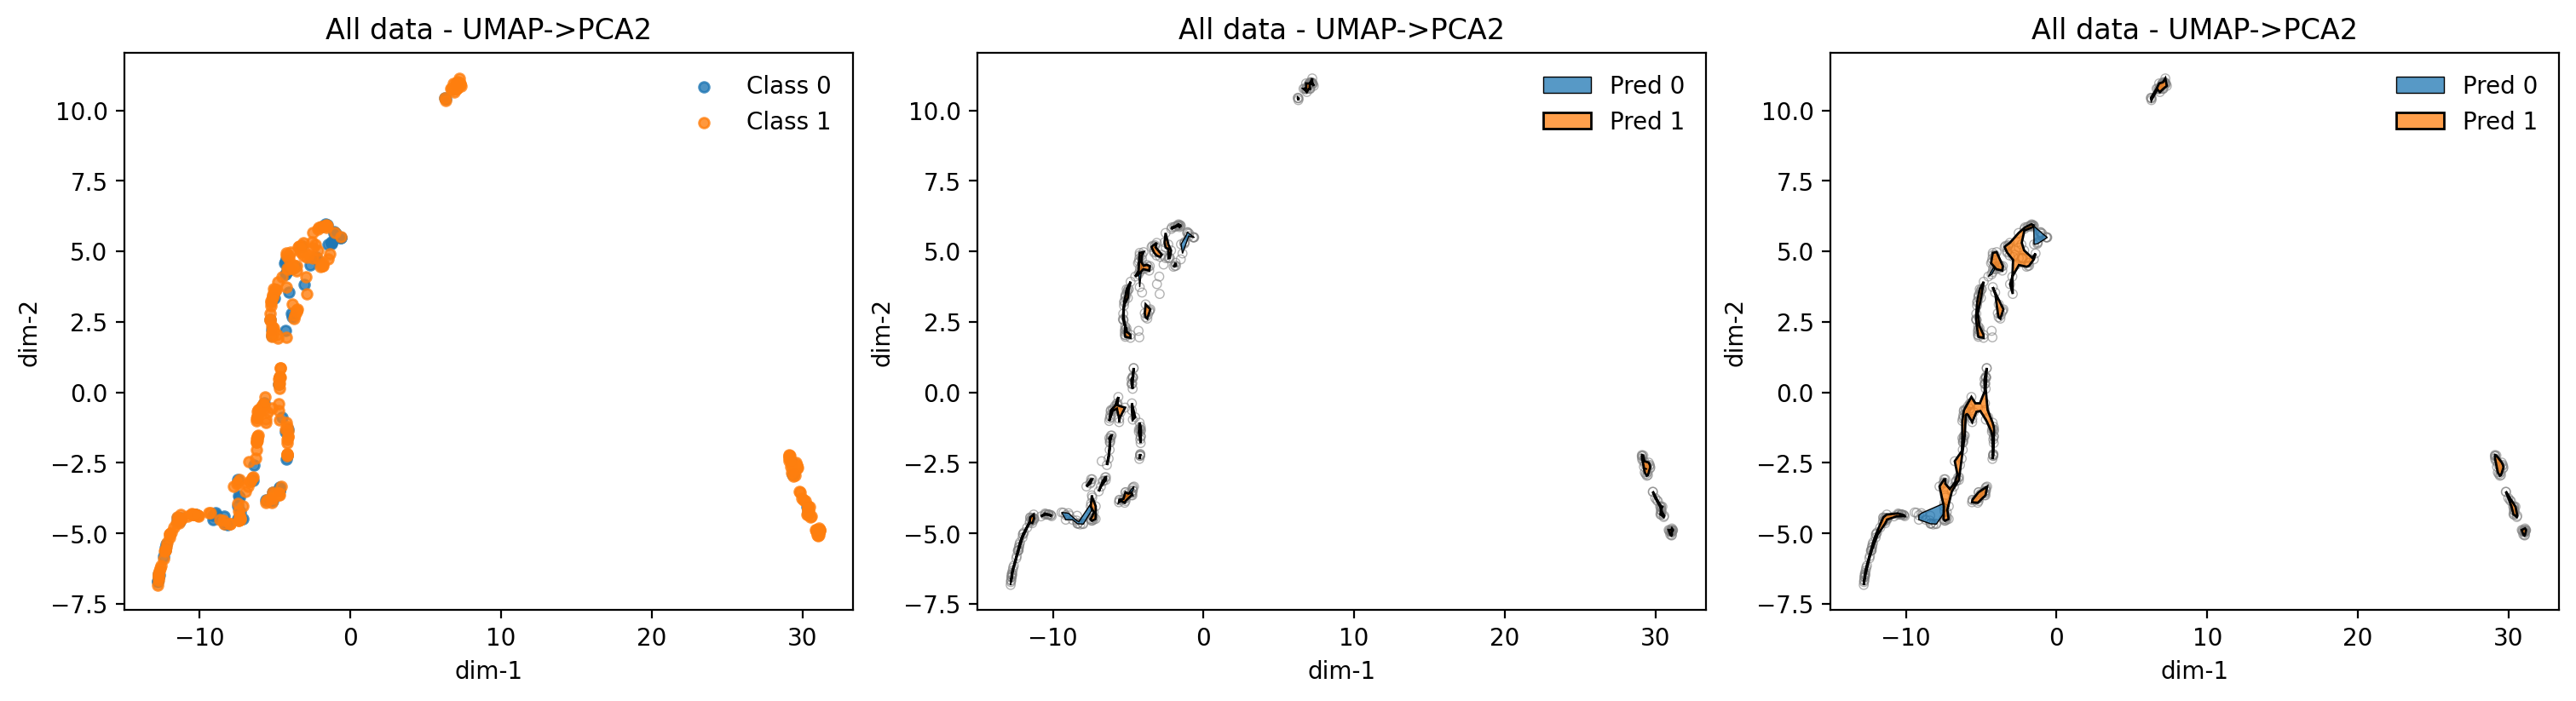

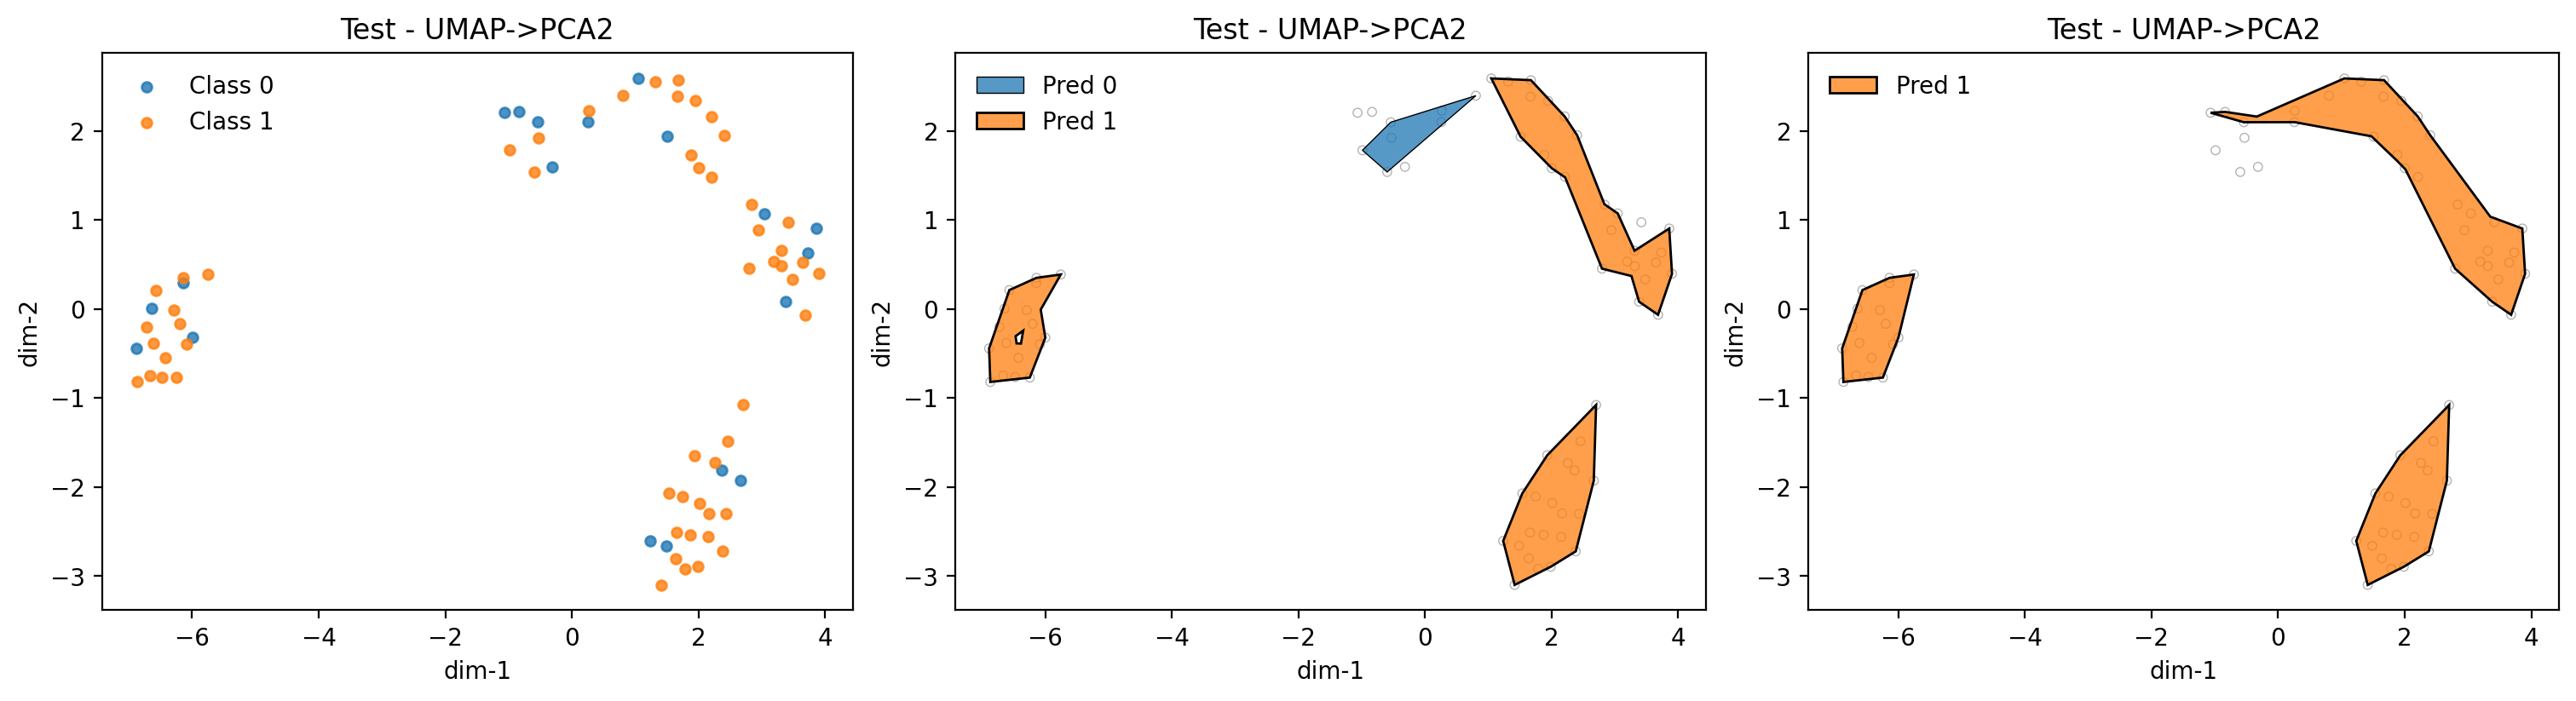

    Classifier: random_forest
AID 2631 - cycle - random_forest: accuracy=0.851, roc_auc=0.875, avg_precision=0.945, errors=11, fit_time=2.32s, pred_time=0.79s, total_time=3.11s, n_instances_per_second=118.9


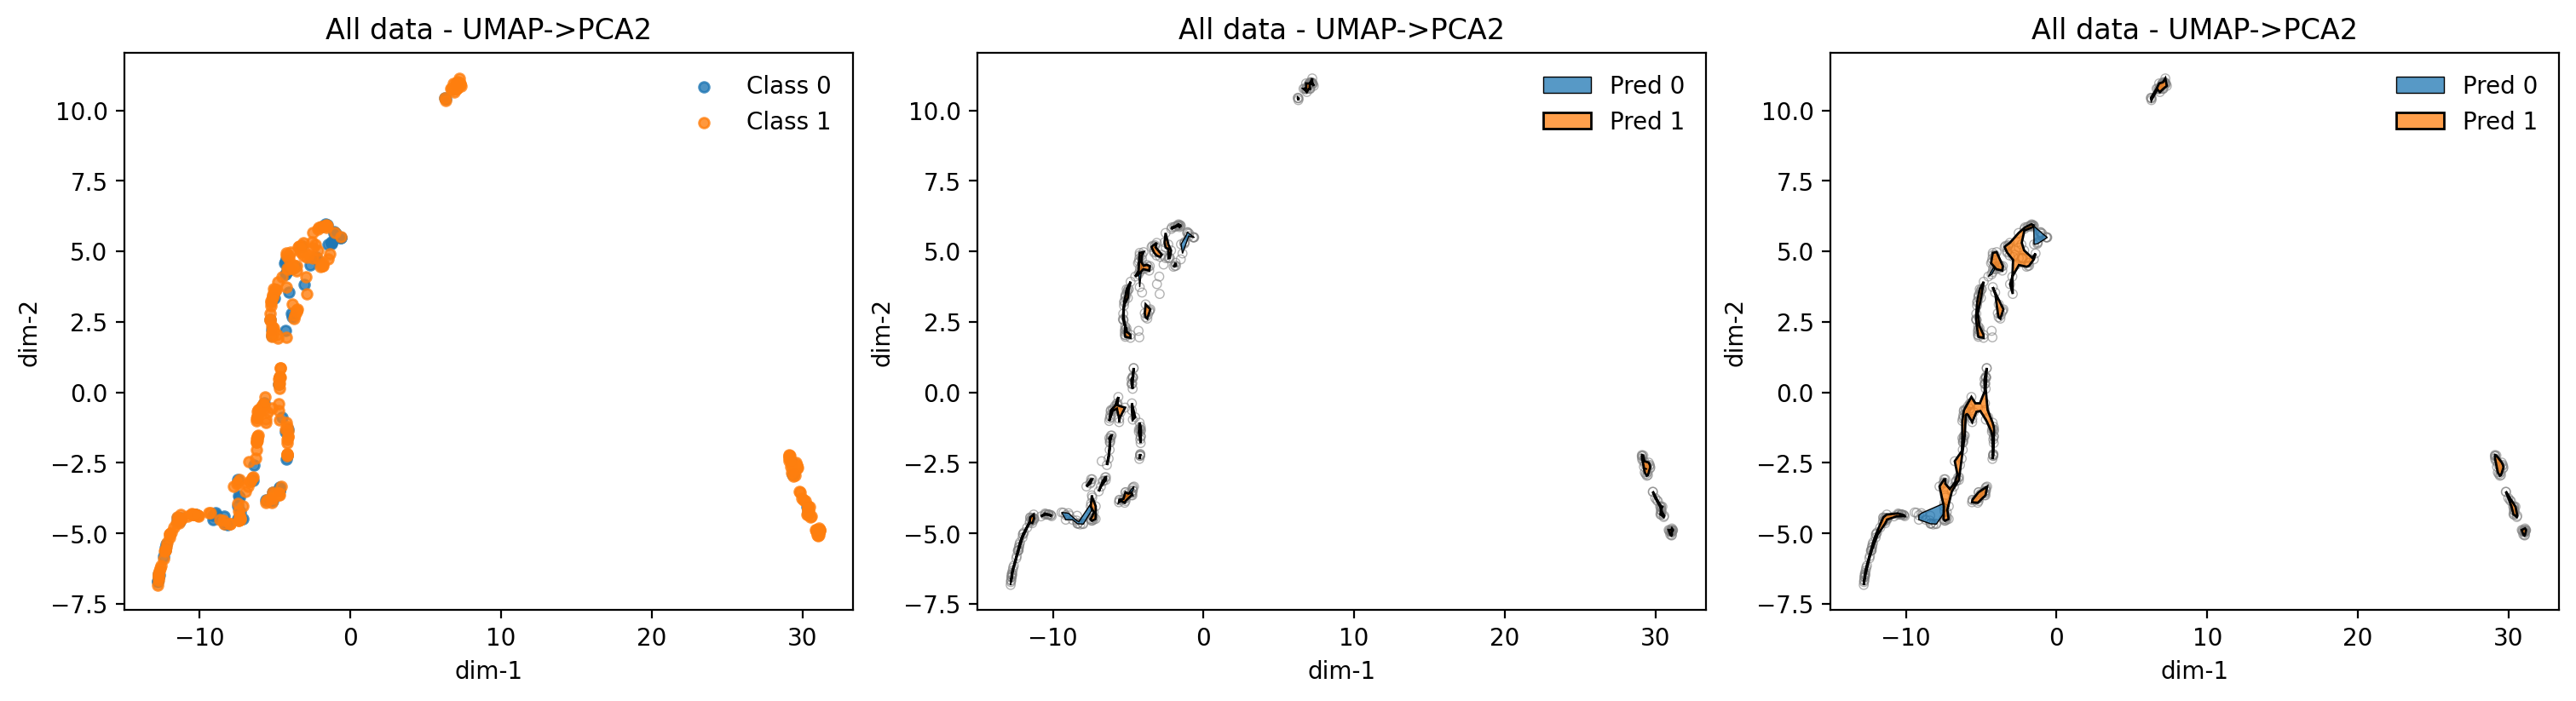

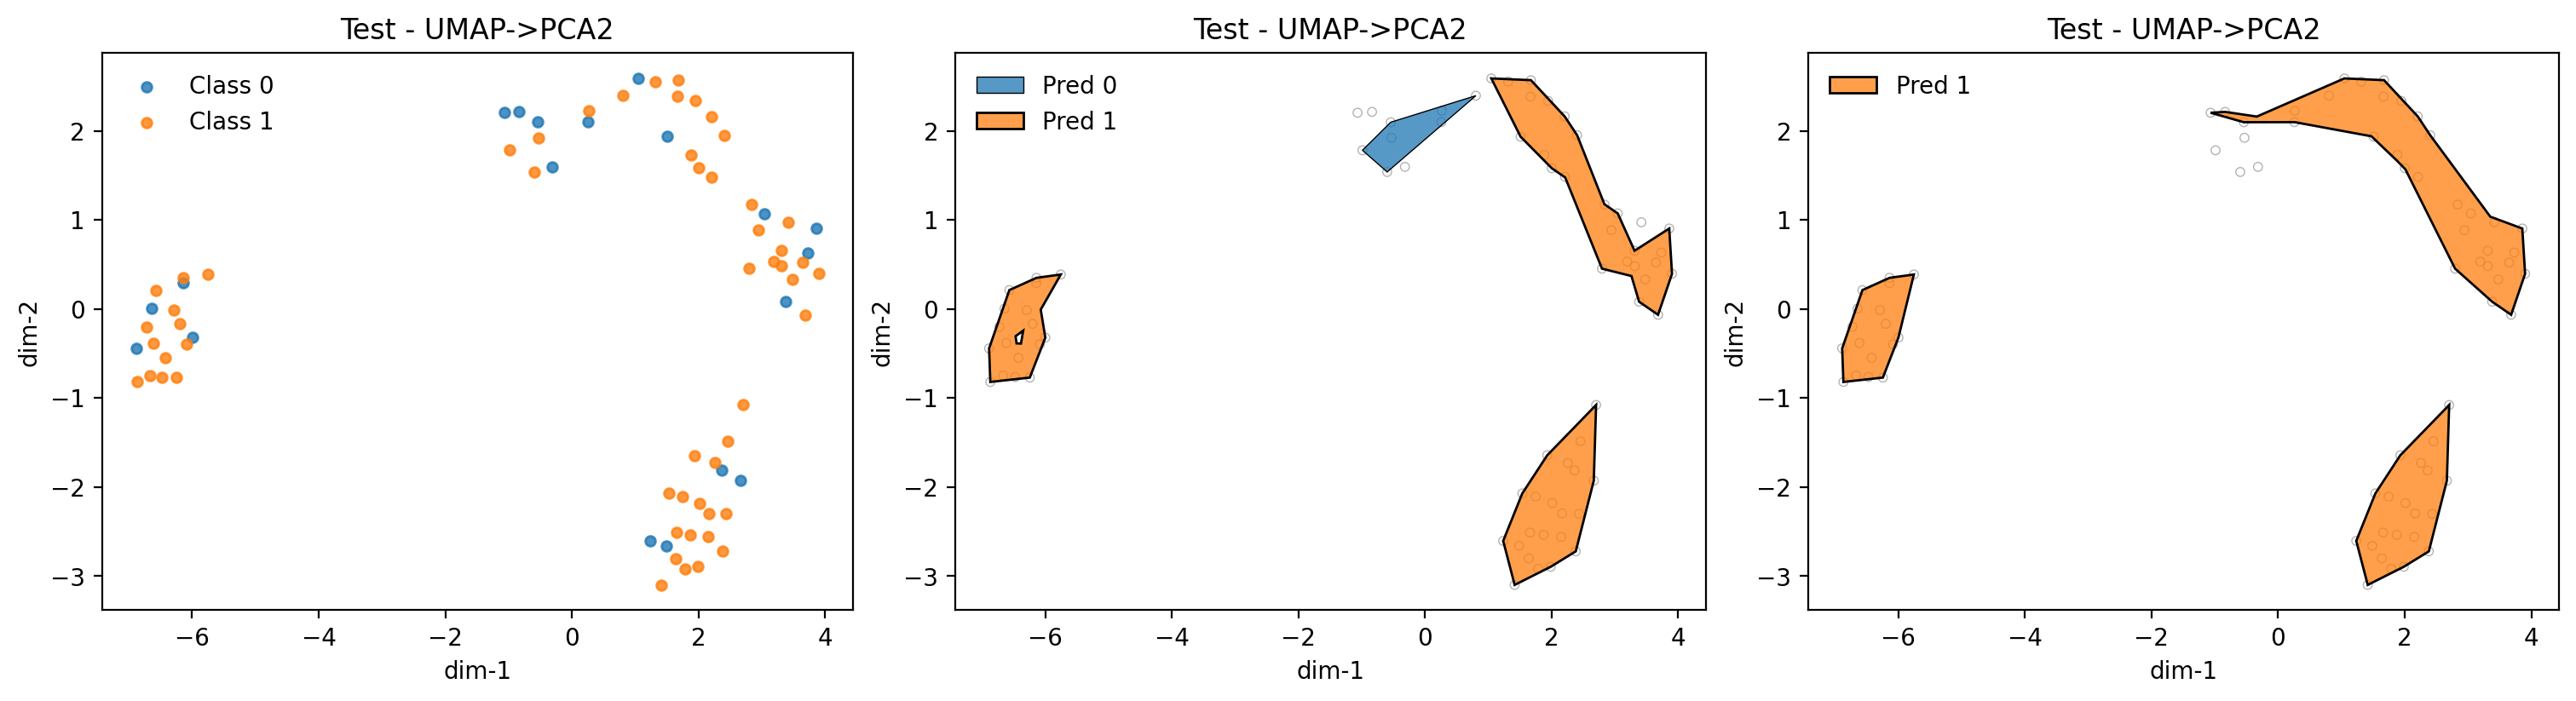

    Classifier: naive_bayes
AID 2631 - cycle - naive_bayes: accuracy=0.743, roc_auc=0.579, avg_precision=0.775, errors=19, fit_time=2.29s, pred_time=0.87s, total_time=3.16s, n_instances_per_second=117.1


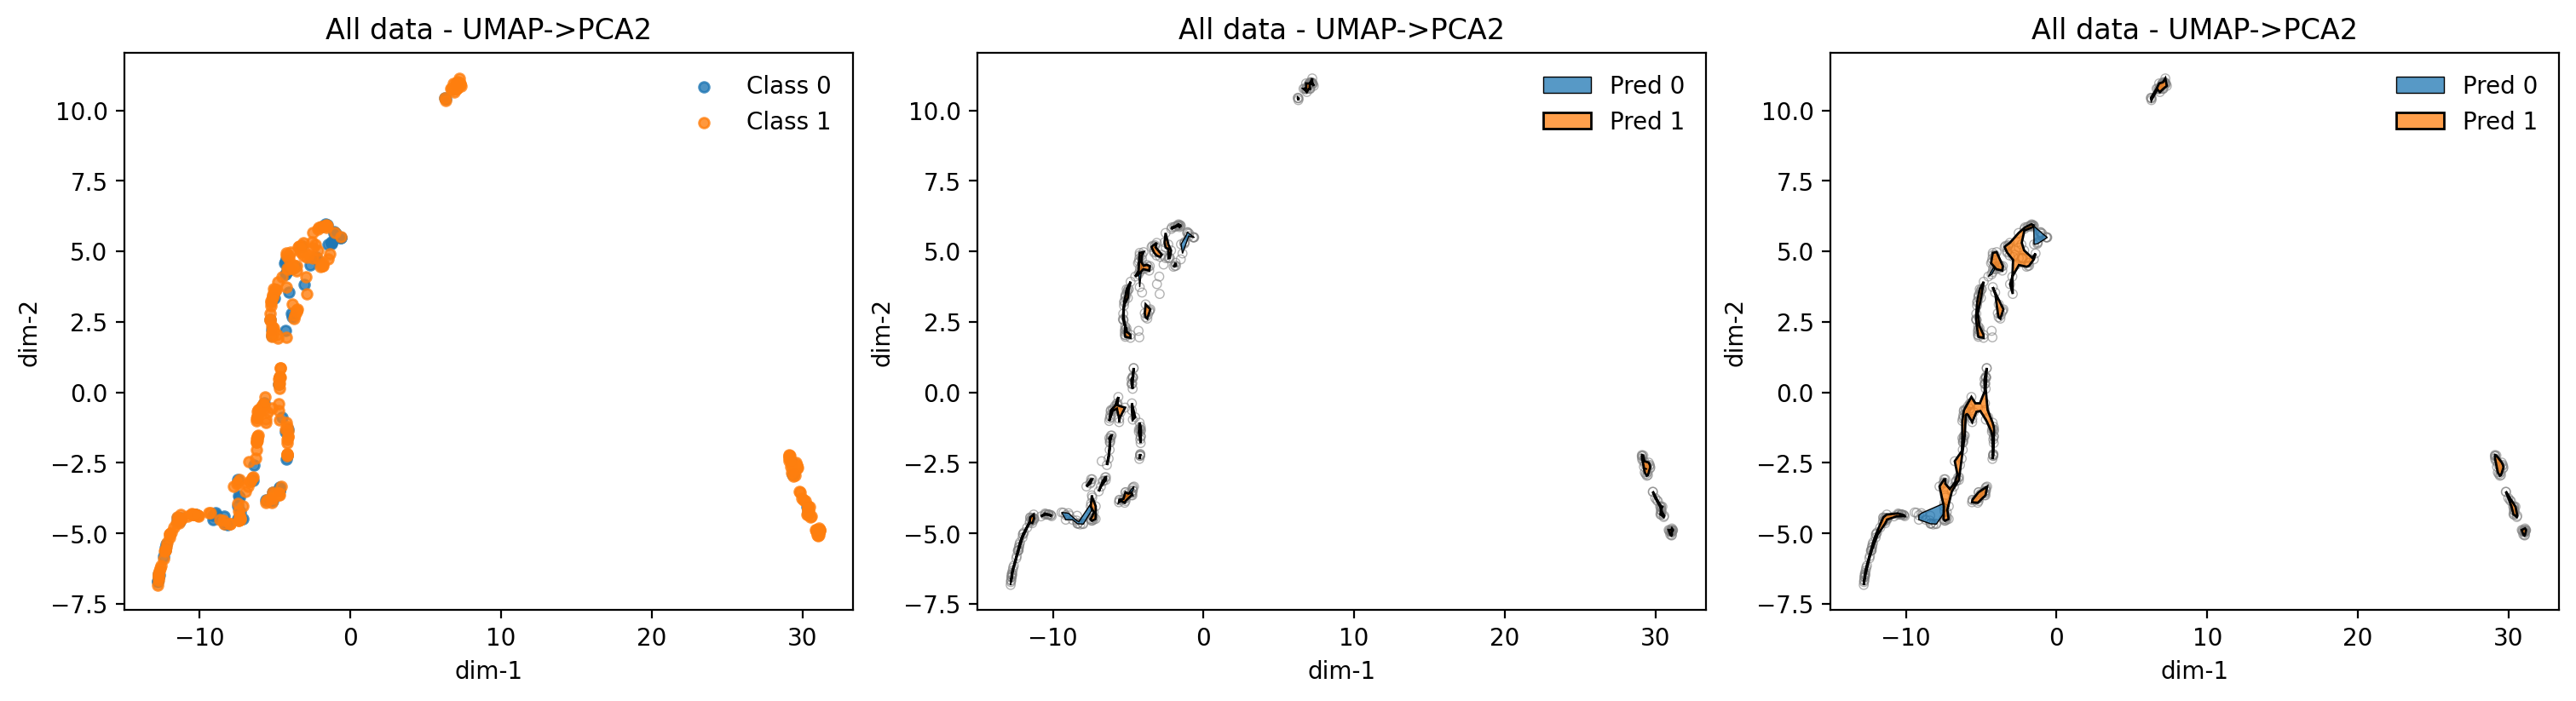

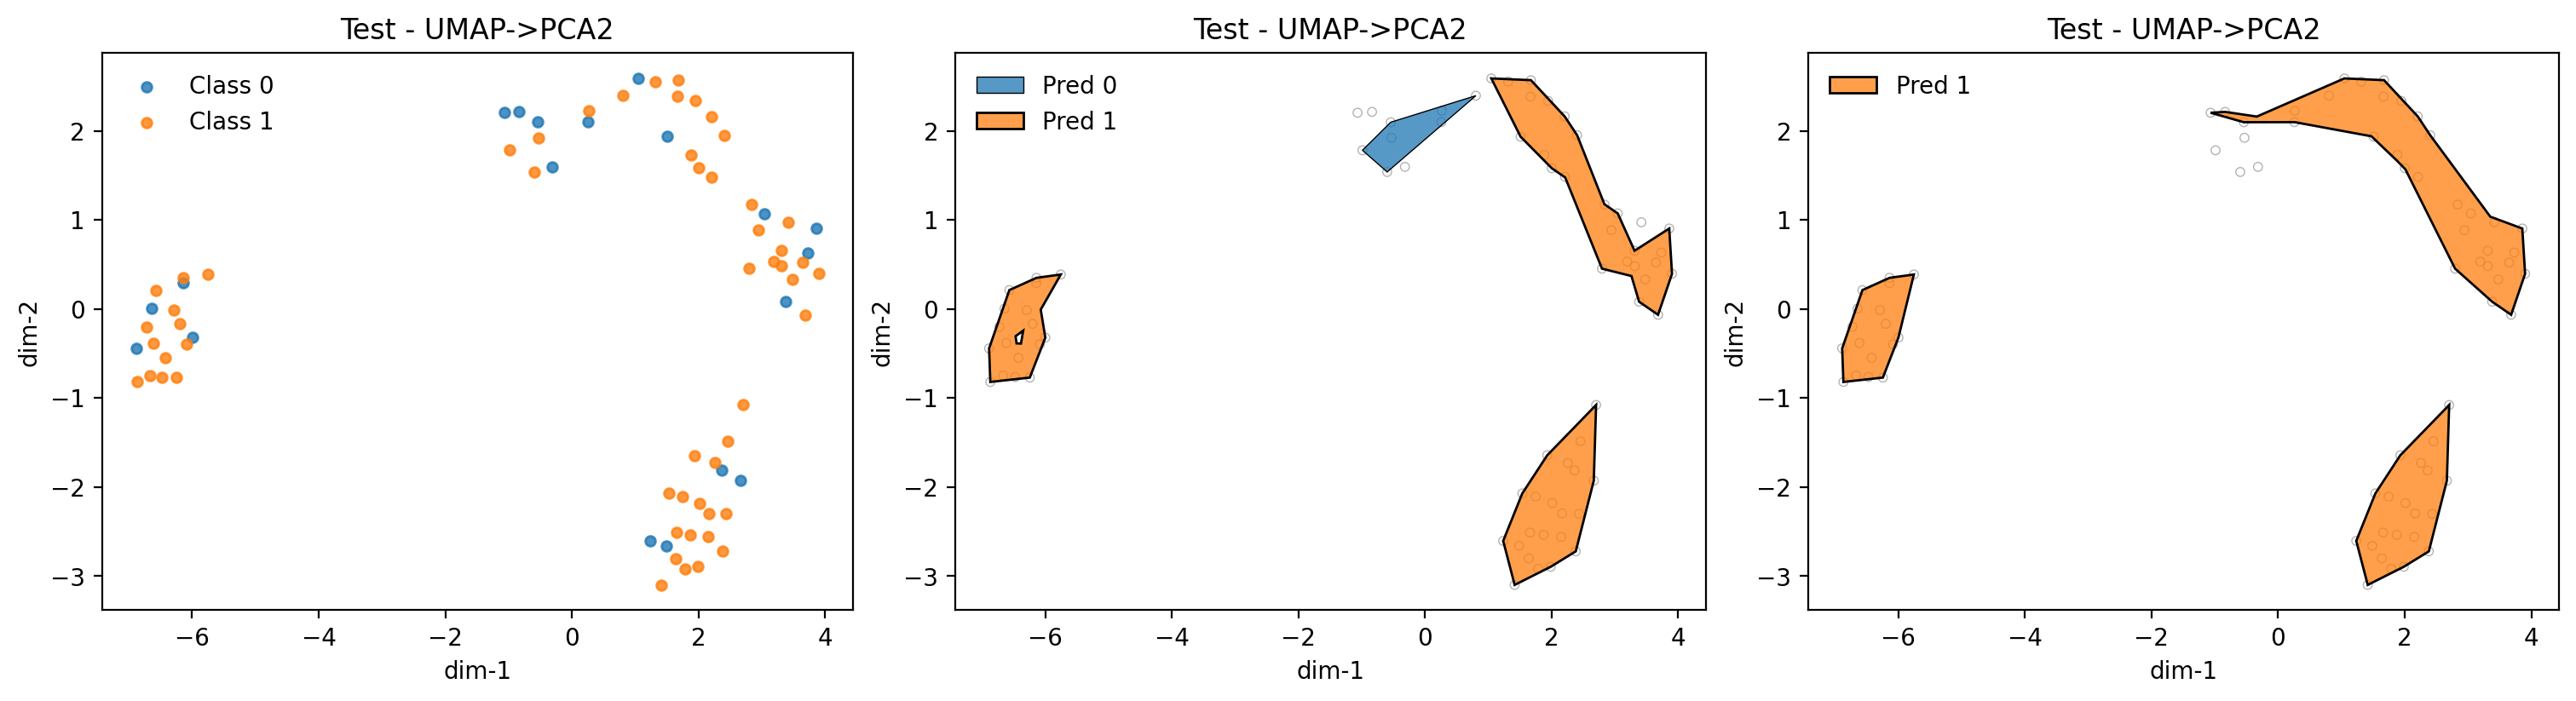

  Decomposition: neighborhood
    Classifier: logistic_regression
AID 2631 - neighborhood - logistic_regression: accuracy=0.838, roc_auc=0.861, avg_precision=0.939, errors=12, fit_time=38.33s, pred_time=19.10s, total_time=57.43s, n_instances_per_second=6.4


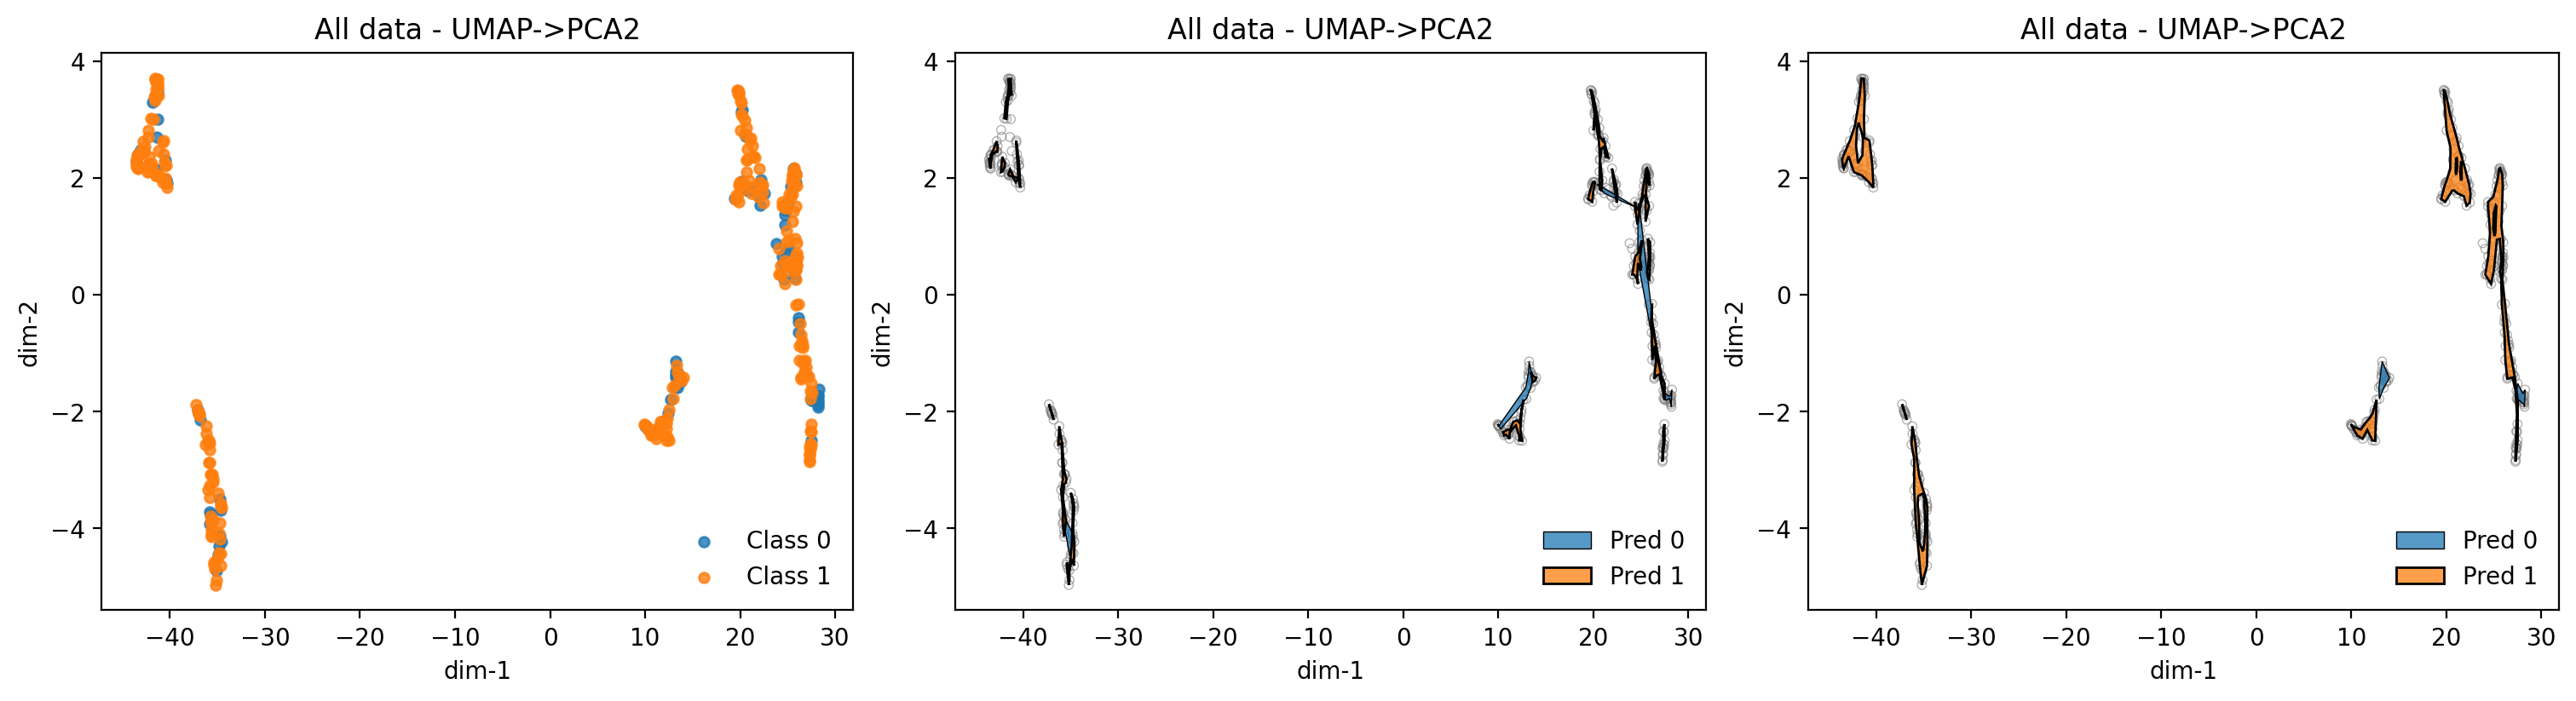

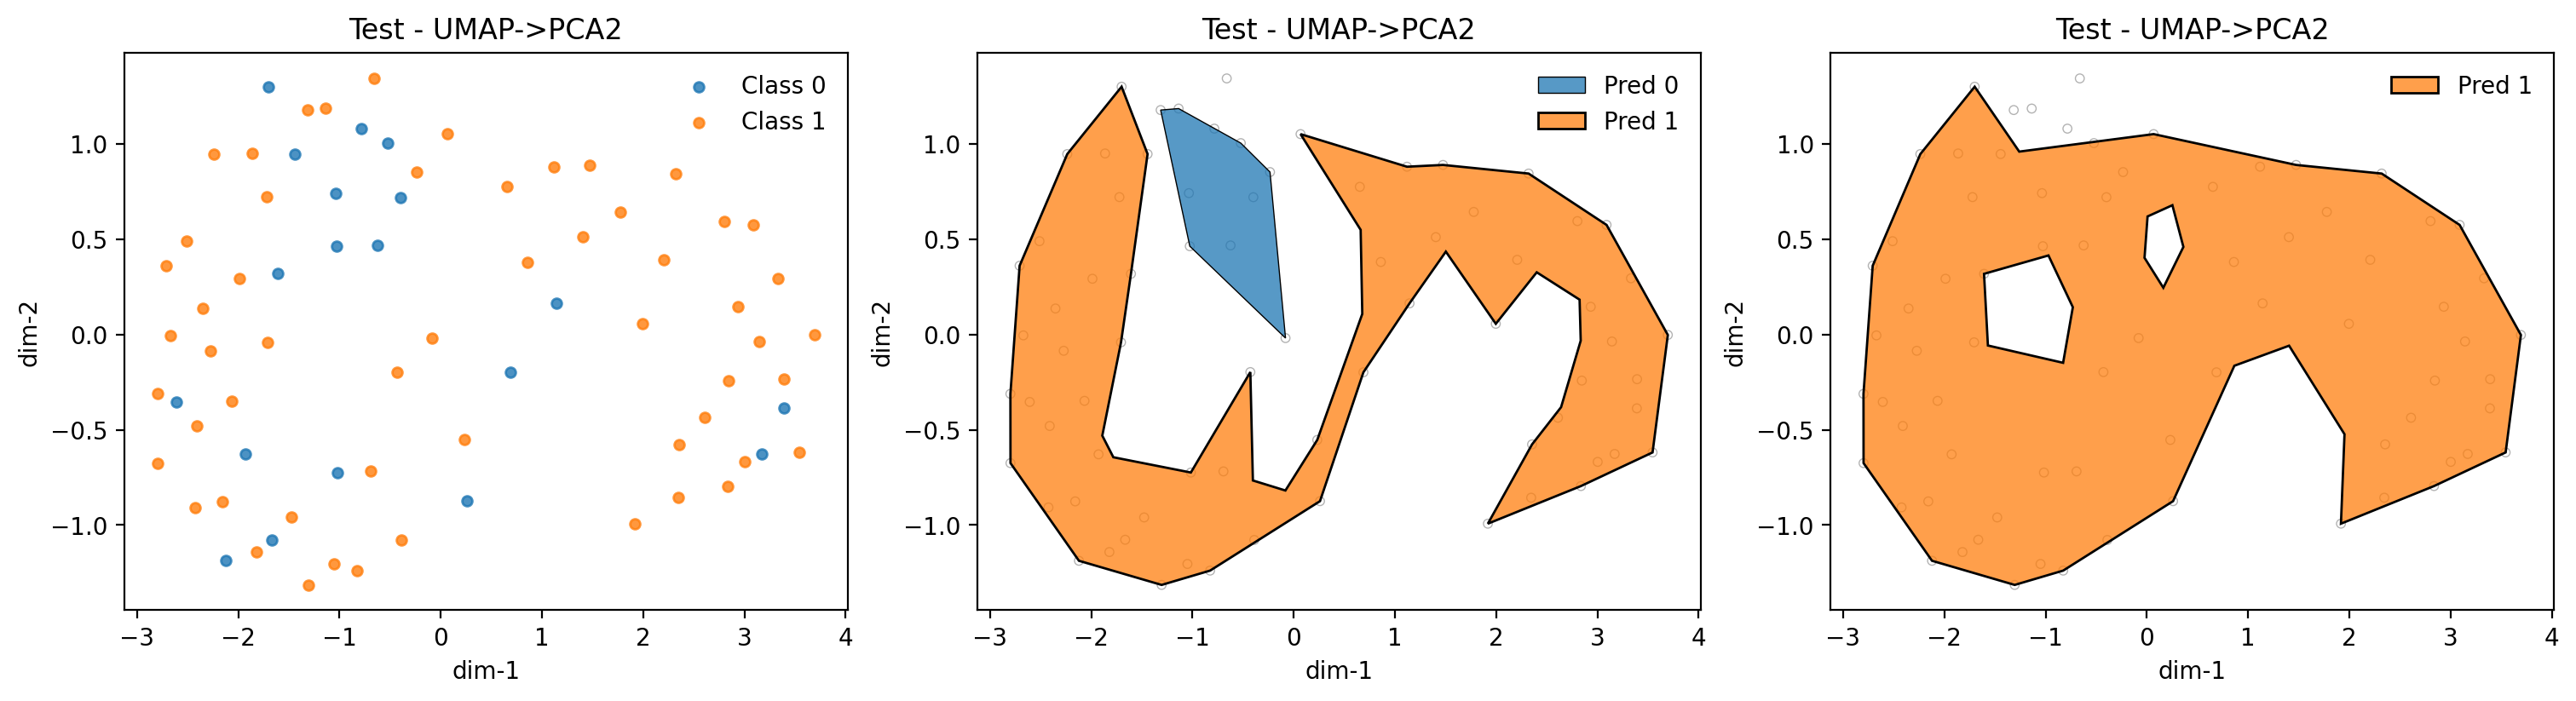

    Classifier: random_forest
AID 2631 - neighborhood - random_forest: accuracy=0.811, roc_auc=0.890, avg_precision=0.958, errors=14, fit_time=34.96s, pred_time=19.23s, total_time=54.20s, n_instances_per_second=6.8
CPU times: user 1min 21s, sys: 18.4 s, total: 1min 39s
Wall time: 6min 47s


KeyboardInterrupt: 

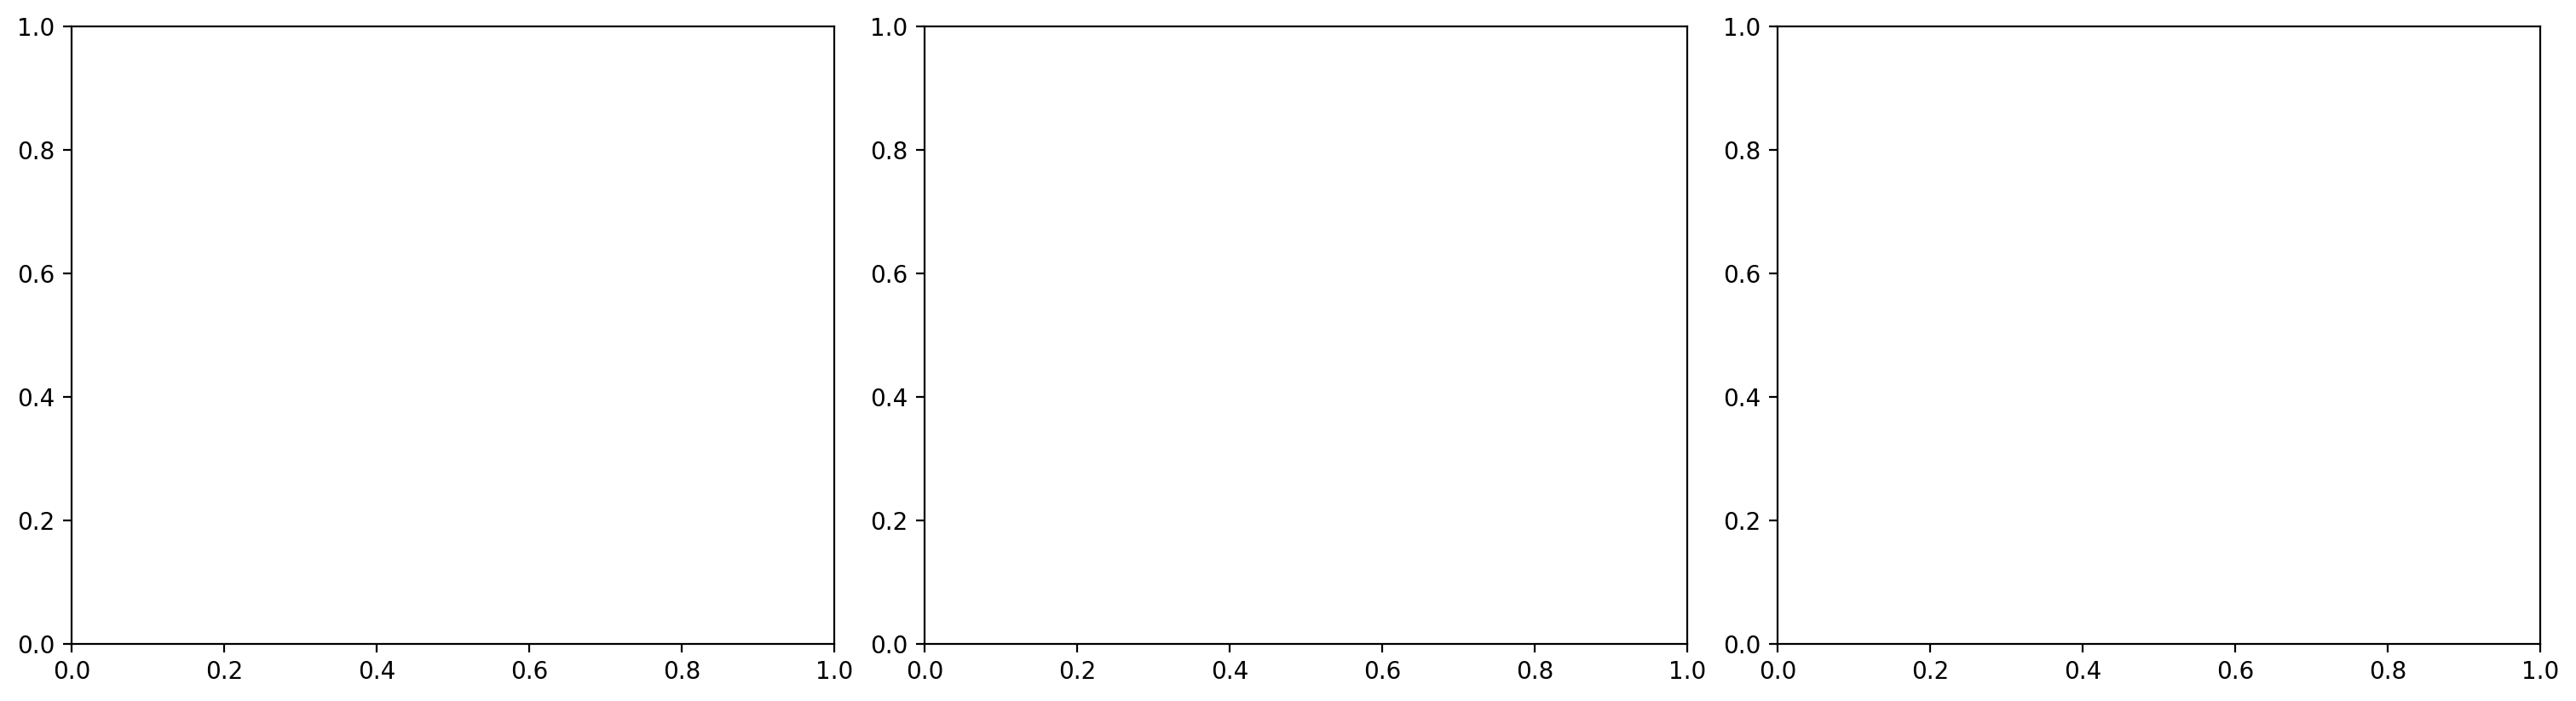

In [15]:
%%time

classifier_specs = [
    ("logistic_regression", lambda: LogisticRegression(random_state=0, max_iter=5000, n_jobs=-1)),
    ("random_forest", lambda: RandomForestClassifier(random_state=0, n_estimators=300, n_jobs=-1)),
    ("naive_bayes", lambda: MultinomialNB()),
]

reports = []

for assay_id, graphs, targets in datasets:
    print(f"\nProcessing assay {assay_id} (n={len(graphs)})")
    graphs_train, graphs_test, targets_train, targets_test = train_test_split(
        graphs,
        targets,
        test_size=0.2,
        random_state=42,
        stratify=targets,
    )

    for decomposition_name, decomposition_fn in decomposition_functions:
        print(f"  Decomposition: {decomposition_name}")
        for classifier_name, make_classifier in classifier_specs:
            print(f"    Classifier: {classifier_name}")
            transformer = AbstractGraphTransformer(
                nbits=14,
                decomposition_function=decomposition_fn,
                return_dense=True,
                n_jobs=-1,  # avoid multiprocessing pickling issues in notebooks
            )

            graph_estimator = GraphEstimator(
                transformer=transformer,
                estimator=make_classifier(),
                manifold=None,
                n_selected_features=500,
            )

            start_total = time.perf_counter()

            start_fit = time.perf_counter()
            graph_estimator.fit(graphs_train, targets_train)
            fit_time = time.perf_counter() - start_fit

            acc, auc, ap, errors, pred_time = perf(graph_estimator, graphs_test, targets_test)
            total_time = time.perf_counter() - start_total
            print_perf(
                f'AID {assay_id} - {decomposition_name} - {classifier_name}',
                acc,
                auc,
                ap,
                errors,
                fit_time,
                pred_time,
                len(graphs),
            )

            reports.append(
                {
                    "assay_id": assay_id,
                    "decomposition": decomposition_name,
                    "classifier": classifier_name,
                    "accuracy": acc,
                    "roc_auc": auc,
                    "avg_precision": ap,
                    "errors": errors,
                    "fit_time": fit_time,
                    "pred_time": pred_time,
                    "total_time": total_time,
                    "n_instances_per_second": len(graphs) / total_time if total_time > 0 else float("inf"),
                }
            )

            # Visualize embeddings using helper
            plot(graph_estimator, graphs, targets, graphs_test, targets_test)


In [ ]:
report_df = pd.DataFrame(reports)
display(report_df)

plot_benchmark_comparison(report_df, metric="accuracy")
plot_benchmark_comparison(report_df, metric="roc_auc")
plot_benchmark_comparison(report_df, metric="avg_precision")

---